# Capstone 8 - Movie Recommendation System

This notebook downloads MovieLens Small, explores its movies and ratings, and recommends similar movies using genres and tags. Every code step includes a comment. Run the cells from top to bottom.


## 1. Data collection

The first code cell downloads MovieLens Small automatically. You need internet access the first time you run it. If an import fails, install the packages with `%pip install pandas matplotlib scikit-learn` in a new cell, then restart and run again.


In [2]:
# Path helps us create folders and locate files.
from pathlib import Path
# urlretrieve downloads the dataset from its web address.
from urllib.request import urlretrieve
# ZipFile opens and extracts the downloaded ZIP file.
from zipfile import ZipFile
# pandas reads and works with tables.
import pandas as pd
# matplotlib draws graphs.
import matplotlib.pyplot as plt
# TF-IDF turns movie genres and tags into numbers.
from sklearn.feature_extraction.text import TfidfVectorizer
# cosine_similarity measures how similar two movie profiles are.
from sklearn.metrics.pairwise import cosine_similarity
# display shows neat tables in Jupyter.
from IPython.display import display

# Use the folder containing this notebook as our project folder.
PROJECT_ROOT = Path.cwd()
# Make a folder for the original MovieLens files.
DATA_DIR = PROJECT_ROOT / 'data' / 'raw'
# Make a folder for the project results.
OUTPUT_DIR = PROJECT_ROOT / 'outputs'
# Create both folders if they do not exist.
DATA_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
# Give the official MovieLens Small download address.
URL = 'https://files.grouplens.org/datasets/movielens/ml-latest-small.zip'
# Choose where to save the ZIP file.
ZIP_PATH = DATA_DIR / 'ml-latest-small.zip'
# Choose the folder that contains the CSV files after extraction.
MOVIELENS_DIR = DATA_DIR / 'ml-latest-small'
# Download the data only if it has not already been extracted.
if not (MOVIELENS_DIR / 'movies.csv').exists():
    # Download the ZIP if it is not already on your computer.
    if not ZIP_PATH.exists():
        # Tell the user what the notebook is doing.
        print('Downloading MovieLens Small...')
        # Download the ZIP file.
        urlretrieve(URL, ZIP_PATH)
    # Open the ZIP file after downloading it.
    with ZipFile(ZIP_PATH) as zip_file:
        # Extract its files into the data folder.
        zip_file.extractall(DATA_DIR)
# Show where the dataset was saved.
print('Dataset ready:', MOVIELENS_DIR)

Dataset ready: C:\Users\user\Capstone Project\Capstone project_! final\notebooks\data\raw\ml-latest-small


## 2. Data loading and verification

In [3]:
# Read the movie titles and genres.
movies = pd.read_csv(MOVIELENS_DIR / 'movies.csv')
# Read the user ratings.
ratings = pd.read_csv(MOVIELENS_DIR / 'ratings.csv')
# Read the user-written tags.
tags = pd.read_csv(MOVIELENS_DIR / 'tags.csv')
# Print the number of rows and columns in each table.
print('Movies:', movies.shape)
print('Ratings:', ratings.shape)
print('Tags:', tags.shape)
# Show the first five rows of each table.
display(movies.head())
display(ratings.head())
display(tags.head())

Movies: (9742, 3)
Ratings: (100836, 4)
Tags: (3683, 4)


,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931


,userId,movieId,tag,timestamp
0,2,60756,funny,1445714994
1,2,60756,Highly quotable,1445714996
2,2,60756,will ferrell,1445714992
3,2,89774,Boxing story,1445715207
4,2,89774,MMA,1445715200


In [4]:
# Count missing values in each table.
print('Missing movie values:\n', movies.isna().sum())
print('Missing rating values:\n', ratings.isna().sum())
print('Missing tag values:\n', tags.isna().sum())
# Count exact duplicate rows before removing them.
print('Duplicate movie rows:', movies.duplicated().sum())
print('Duplicate rating rows:', ratings.duplicated().sum())
print('Duplicate tag rows:', tags.duplicated().sum())
# Remove exact duplicates from the movie table.
movies = movies.drop_duplicates().copy()
# Remove exact duplicates from the ratings table.
ratings = ratings.drop_duplicates().copy()
# Remove exact duplicates from the tags table.
tags = tags.drop_duplicates().copy()
# Replace a missing tag with empty text so the text model can use it.
tags['tag'] = tags['tag'].fillna('')

Missing movie values:
 movieId    0
title      0
genres     0
dtype: int64
Missing rating values:
 userId       0
movieId      0
rating       0
timestamp    0
dtype: int64
Missing tag values:
 userId       0
movieId      0
tag          0
timestamp    0
dtype: int64
Duplicate movie rows: 0
Duplicate rating rows: 0
Duplicate tag rows: 0


## 3. Exploratory data analysis

In [5]:
# Count unique users.
number_of_users = ratings['userId'].nunique()
# Count all movies in the movie table.
number_of_movies = movies['movieId'].nunique()
# Count movies that received at least one rating.
number_of_rated_movies = ratings['movieId'].nunique()
# Count all rating rows.
number_of_ratings = len(ratings)
# Count the possible user-by-rated-movie pairs.
possible_ratings = number_of_users * number_of_rated_movies
# Calculate the percentage of pairs without a rating.
sparsity = 100 * (1 - number_of_ratings / possible_ratings)
# Print each result in a readable way.
print('Users:', number_of_users)
print('Movies in catalogue:', number_of_movies)
print('Movies with ratings:', number_of_rated_movies)
print('Number of ratings:', number_of_ratings)
print('Average rating:', round(ratings['rating'].mean(), 2))
print('Missing user-movie ratings:', round(sparsity, 2), '%')

Users: 610
Movies in catalogue: 9742
Movies with ratings: 9724
Number of ratings: 100836
Average rating: 3.5
Missing user-movie ratings: 98.3 %


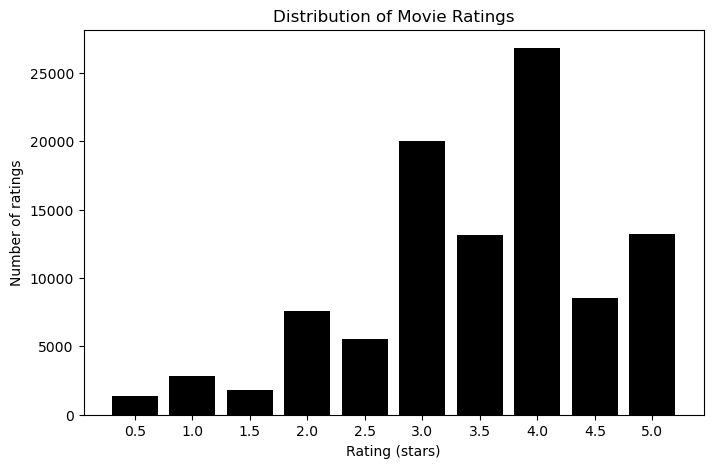

In [15]:
# Count how often each rating value appears.
rating_counts = ratings['rating'].value_counts().sort_index()
# Create a figure for the chart.
plt.figure(figsize=(8, 5))
# Draw one bar for each rating value.
plt.bar(rating_counts.index.astype(str), rating_counts.values, color='black')
# Add a title and axis labels.
plt.title('Distribution of Movie Ratings')
plt.xlabel('Rating (stars)')
plt.ylabel('Number of ratings')
# Save the chart for the report.
plt.savefig(OUTPUT_DIR / 'rating_distribution.png', bbox_inches='tight')
# Show the chart in the notebook.
plt.show()

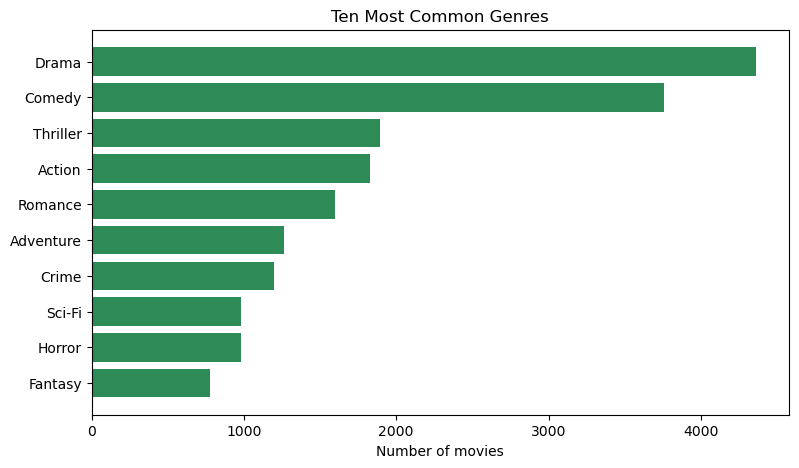

Most users rated only a small fraction of the available movies.


In [7]:
# Separate each movie's genres into a list.
genre_lists = movies['genres'].fillna('').str.split('|')
# Put all genre lists into one long column.
all_genres = genre_lists.explode()
# Exclude movies without a listed genre.
all_genres = all_genres[all_genres != '(no genres listed)']
# Count the ten most common genres.
top_genres = all_genres.value_counts().head(10)
# Create a chart area.
plt.figure(figsize=(9, 5))
# Draw a horizontal bar for each genre.
plt.barh(top_genres.index[::-1], top_genres.values[::-1], color='seagreen')
# Add a title and axis label.
plt.title('Ten Most Common Genres')
plt.xlabel('Number of movies')
# Save the chart.
plt.savefig(OUTPUT_DIR / 'top_genres.png', bbox_inches='tight')
# Show the chart.
plt.show()
# Describe what the sparsity calculation means.
print('Most users rated only a small fraction of the available movies.')

## 4. Feature creation

We combine genres and tags into text for each movie. TF-IDF converts the text to numbers; cosine similarity later compares these numbers.


In [8]:
# Convert tag text to lowercase, then combine all tags for each movie.
tags['tag'] = tags['tag'].str.lower()
tag_text = tags.groupby('movieId')['tag'].apply(' '.join).reset_index()
# Give the combined text column a clear name.
tag_text = tag_text.rename(columns={'tag': 'tag_text'})
# Calculate each movie's average rating and number of ratings.
rating_stats = ratings.groupby('movieId')['rating'].agg(['mean', 'count']).reset_index()
# Name the two new columns clearly.
rating_stats = rating_stats.rename(columns={'mean': 'avg_rating', 'count': 'rating_count'})
# Add the combined tags to the movie table.
movie_features = movies.merge(tag_text, on='movieId', how='left')
# Add the rating statistics to the movie table.
movie_features = movie_features.merge(rating_stats, on='movieId', how='left')
# Replace movies' missing tags with empty text.
movie_features['tag_text'] = movie_features['tag_text'].fillna('')
# Use zero for movies that have no ratings.
movie_features['rating_count'] = movie_features['rating_count'].fillna(0).astype(int)
# Replace missing average ratings with zero for display only.
movie_features['avg_rating'] = movie_features['avg_rating'].fillna(0)
# Change genre separators to spaces for the text model.
movie_features['genre_text'] = movie_features['genres'].fillna('').str.replace('|', ' ', regex=False)
# Remove the placeholder for movies with no known genres.
movie_features['genre_text'] = movie_features['genre_text'].str.replace('(no genres listed)', '', regex=False)
# Combine genres and tags into one text profile per movie.
movie_features['content'] = movie_features['genre_text'] + ' ' + movie_features['tag_text']
# Create the tool that converts text to numerical features.
vectorizer = TfidfVectorizer(stop_words='english')
# Build one numerical row for every movie.
tfidf_matrix = vectorizer.fit_transform(movie_features['content'])
# Print the feature matrix size and preview the movie profiles.
print('Feature matrix:', tfidf_matrix.shape)
display(movie_features[['movieId', 'title', 'genres', 'tag_text']].head())

Feature matrix: (9742, 1675)


,movieId,title,genres,tag_text
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,pixar pixar fun
1,2,Jumanji (1995),Adventure|Children|Fantasy,fantasy magic board game robin williams game
2,3,Grumpier Old Men (1995),Comedy|Romance,moldy old
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance,
4,5,Father of the Bride Part II (1995),Comedy,pregnancy remake


## 5. Similarity, ranking, and explanations

The main example ranks movies by similarity. An optional second table blends similarity with movie ratings.


In [9]:
# Find titles containing the user's search words.
def find_titles(search_text):
    # Compare movie titles without treating the search text as a special pattern.
    matches = movie_features['title'].str.contains(search_text, case=False, regex=False)
    # Show the first ten matching movies.
    return movie_features.loc[matches, ['movieId', 'title', 'genres']].head(10)

# Explain which genres a recommended movie shares with the selected movie.
def explain_match(selected_movie, recommended_movie):
    # Split the selected movie's genres into a set.
    selected_genres = set(selected_movie['genres'].split('|'))
    # Split the recommended movie's genres into a set.
    recommended_genres = set(recommended_movie['genres'].split('|'))
    # Find the genres found in both movies.
    shared = selected_genres.intersection(recommended_genres)
    # Remove the placeholder if neither movie has listed genres.
    shared.discard('(no genres listed)')
    # Give a short explanation when genres overlap.
    if shared:
        # Join the matching genres into one readable sentence.
        return 'Shared genres: ' + ', '.join(sorted(shared))
    # Tags can make movies similar even without matching genres.
    return 'Similar movie tags or text profile'

# Recommend movies similar to one selected movie.
def recommend_movies(title, top_n=10, blend_ratings=False, min_ratings=0):
    # Find movies whose title matches exactly, ignoring capitalization.
    matches = movie_features[movie_features['title'].str.lower() == title.lower()]
    # Stop with a helpful message if the title is not present.
    if matches.empty:
        # Tell the user how to look for an exact title.
        raise ValueError('Title not found. Try find_titles("part of a title").')
    # Get the row number of the selected movie.
    selected_index = matches.index[0]
    # Get the selected movie and its metadata.
    selected_movie = movie_features.loc[selected_index]
    # Compare that movie's TF-IDF row with all other movie rows.
    scores = cosine_similarity(tfidf_matrix[selected_index], tfidf_matrix).flatten()
    # Copy the movie data so the original table stays intact.
    candidates = movie_features.copy()
    # Add the similarity score to each candidate movie.
    candidates['similarity'] = scores
    # Remove the selected movie from the results.
    candidates = candidates[candidates.index != selected_index].copy()
    # Exclude movies with fewer than the requested number of ratings.
    candidates = candidates[candidates['rating_count'] >= min_ratings].copy()
    # Start with similarity as the ranking score.
    candidates['score'] = candidates['similarity']
    # Optionally use average rating as a small part of the score.
    if blend_ratings:
        # Use 20 extra votes at the overall average to reduce noisy high ratings.
        overall_average = ratings['rating'].mean()
        # Calculate a weighted average of a movie's rating and the overall rating.
        weighted_rating = (candidates['rating_count'] * candidates['avg_rating'] + 20 * overall_average) / (candidates['rating_count'] + 20)
        # Blend 85% similarity with 15% rating (scaled from 0 to 1).
        candidates['score'] = 0.85 * candidates['similarity'] + 0.15 * weighted_rating / 5
    # Sort by score, breaking ties with the number of ratings.
    candidates = candidates.sort_values(['score', 'rating_count'], ascending=False)
    # Keep only the requested number of movies.
    results = candidates.head(top_n).copy()
    # Add a short explanation for each movie.
    results['why_recommended'] = results.apply(lambda movie: explain_match(selected_movie, movie), axis=1)
    # Choose the columns shown in the final table.
    columns = ['movieId', 'title', 'genres', 'similarity', 'avg_rating', 'rating_count', 'score', 'why_recommended']
    # Return a table with short numeric values.
    return results[columns].round(3).reset_index(drop=True)

# Show movie titles containing Toy Story.
display(find_titles('Toy Story'))

,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
2355,3114,Toy Story 2 (1999),Adventure|Animation|Children|Comedy|Fantasy
7355,78499,Toy Story 3 (2010),Adventure|Animation|Children|Comedy|Fantasy|IMAX


## 6. Generate Top-N recommendations

In [10]:
# Choose the movie we want recommendations for.
selected_title = 'Toy Story (1995)'
# Ask the function for ten content-based recommendations.
recommendations = recommend_movies(selected_title, top_n=10)
# Print the selected title.
print('Recommendations similar to:', selected_title)
# Display the recommendation table.
display(recommendations)
# Save the table as a CSV file.
recommendations.to_csv(OUTPUT_DIR / 'recommendations_toy_story.csv', index=False)
# Save the processed movie table for later inspection.
movie_features.to_csv(OUTPUT_DIR / 'movie_features.csv', index=False)
# Optionally produce a second table with a rating-quality blend.
blended_recommendations = recommend_movies(selected_title, top_n=10, blend_ratings=True, min_ratings=5)
# Show the optional blended results.
display(blended_recommendations)
# Save the optional blended results.
blended_recommendations.to_csv(OUTPUT_DIR / 'blended_recommendations.csv', index=False)

Recommendations similar to: Toy Story (1995)


,movieId,title,genres,similarity,avg_rating,rating_count,score,why_recommended
0,2355,"Bug's Life, A (1998)",Adventure|Animation|Children|Comedy,0.862,3.516,92,0.862,"Shared genres: Adventure, Animation, Children,..."
1,3114,Toy Story 2 (1999),Adventure|Animation|Children|Comedy|Fantasy,0.644,3.861,97,0.644,"Shared genres: Adventure, Animation, Children,..."
2,122918,Guardians of the Galaxy 2 (2017),Action|Adventure|Sci-Fi,0.368,3.926,27,0.368,Shared genres: Adventure
3,4886,"Monsters, Inc. (2001)",Adventure|Animation|Children|Comedy|Fantasy,0.358,3.871,132,0.358,"Shared genres: Adventure, Animation, Children,..."
4,2294,Antz (1998),Adventure|Animation|Children|Comedy|Fantasy,0.358,3.244,45,0.358,"Shared genres: Adventure, Animation, Children,..."
5,4016,"Emperor's New Groove, The (2000)",Adventure|Animation|Children|Comedy|Fantasy,0.358,3.716,37,0.358,"Shared genres: Adventure, Animation, Children,..."
6,53121,Shrek the Third (2007),Adventure|Animation|Children|Comedy|Fantasy,0.358,3.024,21,0.358,"Shared genres: Adventure, Animation, Children,..."
7,166461,Moana (2016),Adventure|Animation|Children|Comedy|Fantasy,0.358,3.450,10,0.358,"Shared genres: Adventure, Animation, Children,..."
8,3754,"Adventures of Rocky and Bullwinkle, The (2000)",Adventure|Animation|Children|Comedy|Fantasy,0.358,2.222,9,0.358,"Shared genres: Adventure, Animation, Children,..."
9,136016,The Good Dinosaur (2015),Adventure|Animation|Children|Comedy|Fantasy,0.358,3.000,4,0.358,"Shared genres: Adventure, Animation, Children,..."


,movieId,title,genres,similarity,avg_rating,rating_count,score,why_recommended
0,2355,"Bug's Life, A (1998)",Adventure|Animation|Children|Comedy,0.862,3.516,92,0.838,"Shared genres: Adventure, Animation, Children,..."
1,3114,Toy Story 2 (1999),Adventure|Animation|Children|Comedy|Fantasy,0.644,3.861,97,0.661,"Shared genres: Adventure, Animation, Children,..."
2,122918,Guardians of the Galaxy 2 (2017),Action|Adventure|Sci-Fi,0.368,3.926,27,0.425,Shared genres: Adventure
3,4886,"Monsters, Inc. (2001)",Adventure|Animation|Children|Comedy|Fantasy,0.358,3.871,132,0.419,"Shared genres: Adventure, Animation, Children,..."
4,4016,"Emperor's New Groove, The (2000)",Adventure|Animation|Children|Comedy|Fantasy,0.358,3.716,37,0.413,"Shared genres: Adventure, Animation, Children,..."
5,166461,Moana (2016),Adventure|Animation|Children|Comedy|Fantasy,0.358,3.450,10,0.409,"Shared genres: Adventure, Animation, Children,..."
6,134853,Inside Out (2015),Adventure|Animation|Children|Comedy|Drama|Fantasy,0.347,3.814,43,0.407,"Shared genres: Adventure, Animation, Children,..."
7,2294,Antz (1998),Adventure|Animation|Children|Comedy|Fantasy,0.358,3.244,45,0.404,"Shared genres: Adventure, Animation, Children,..."
8,65261,Ponyo (Gake no ue no Ponyo) (2008),Adventure|Animation|Children|Fantasy,0.345,4.000,11,0.403,"Shared genres: Adventure, Animation, Children,..."
9,53121,Shrek the Third (2007),Adventure|Animation|Children|Comedy|Fantasy,0.358,3.024,21,0.402,"Shared genres: Adventure, Animation, Children,..."


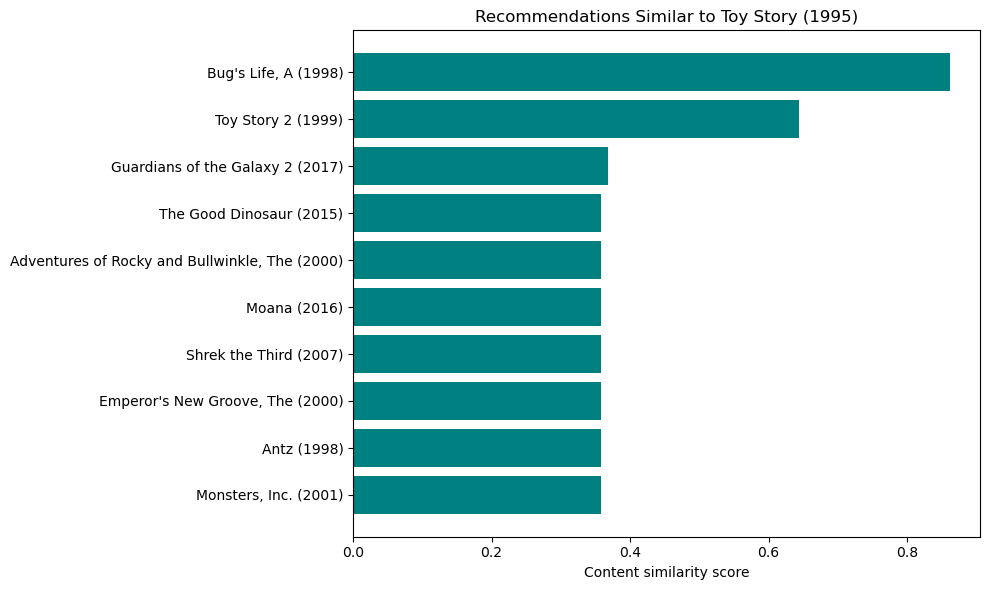

In [14]:
# Sort the recommendations for a horizontal chart.
chart_data = recommendations.sort_values('score')
# Make room for the movie titles.
plt.figure(figsize=(10, 6))
# Draw one bar for each movie's recommendation score.
plt.barh(chart_data['title'], chart_data['score'], color="teal")
# Add the chart title and axis label.
plt.title('Recommendations Similar to ' + selected_title)
plt.xlabel('Content similarity score')
# Fit the labels neatly on the chart.
plt.tight_layout()
# Save a picture for your report.
plt.savefig(OUTPUT_DIR / 'recommendation_scores.png', bbox_inches='tight')
# Show the chart in Jupyter.
plt.show()

## 7. Results and interpretation

The main table and chart rank movies by their genre and tag similarity to Toy Story. Each row includes a short reason based on shared genres. The optional second table adds a small rating-quality component. A higher score means more similar metadata, not a guarantee that someone will enjoy the movie.


## 8. Reflection and possible improvements

This is a content-based recommendation system. It can recommend a movie with no ratings if its genres or tags are known. Tags may be missing, and broad genres can lead to ties. The optional rating component uses overall movie ratings, not ratings from similar users. Future work could evaluate recommendations or learn each user’s preferences.


## Try another movie

Use `find_titles("matrix")` to find its exact title. Then change `selected_title` in section 6 and rerun the last two code cells.
